# Feature EDA
The purpose of this notebook is to perform exploratory data analysis (EDA) using the following features:
1. albumin
2. bicarbonate
3. bun
4. calcium
5. creatinine
6. chloride
7. hemoglobin
8. potassium
9. bun/creatinine
   
For each feature, we begin by constructing histograms to analyze the distribution. Next, to explore feature-target relationships, we create separate histograms for each target class (i.e. kidney disease = 1 and non-kidney disease = 0). Finally, we examine relationships among features by creating pair plots. 

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

In [7]:
data_train = pd.read_csv('../Data/data_train_unscaled.csv')
cols = data_train.columns.tolist()
idx1 = cols.index('class')
idx2 = cols.index('bun_over_creatinine')
cols[idx1], cols[idx2] = cols[idx2], cols[idx1]
data_train = data_train[cols]
data_train.drop(data_train.columns[0],
               axis = 1,
               inplace = True)
data_train.head()

,albumin,bicarbonate,calcium,chloride,creatinine,potassium,bun,hemoglobin,bun_over_creatinine,class
0,3.4,23.0,8.7,97.0,1.2,4.3,23.0,10.7,19.166667,1
1,4.3,20.0,8.8,104.0,0.8,4.0,28.0,14.9,35.000000,0
2,4.8,25.0,9.7,100.0,0.7,4.1,13.0,12.1,18.571429,0
3,3.5,28.0,9.6,107.0,0.6,4.3,13.0,13.8,21.666667,0
4,4.2,26.0,9.5,100.0,1.4,7.8,25.0,11.5,17.857143,1


The next cell constructs a histogram for each feature in order to analyze the distribution. We are looking for skewness or unusual patterns. 

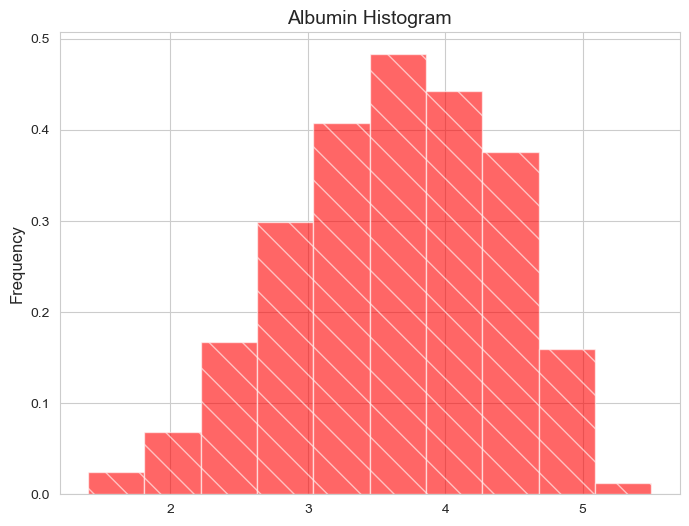

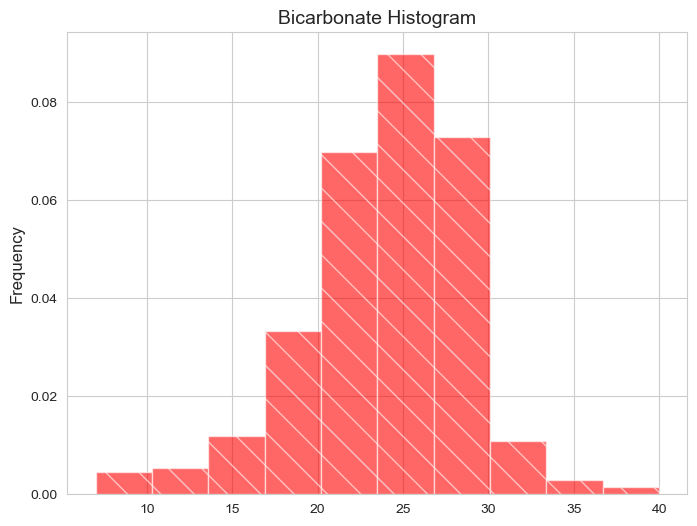

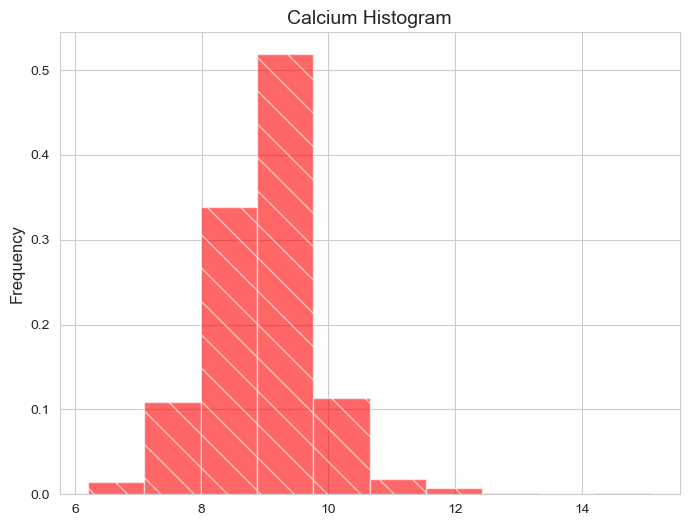

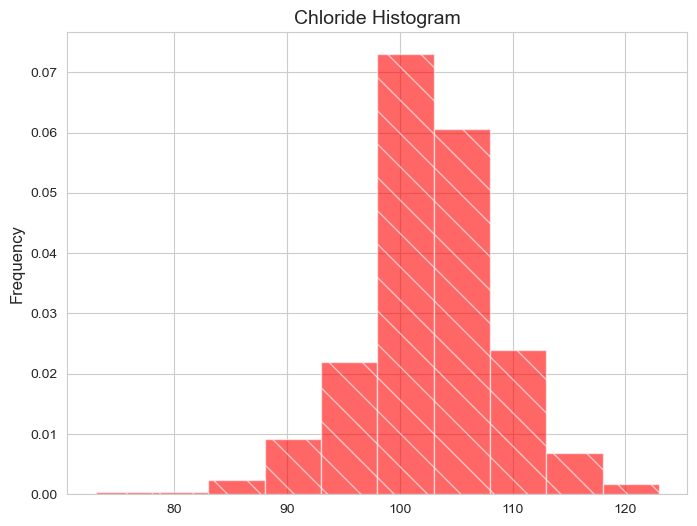

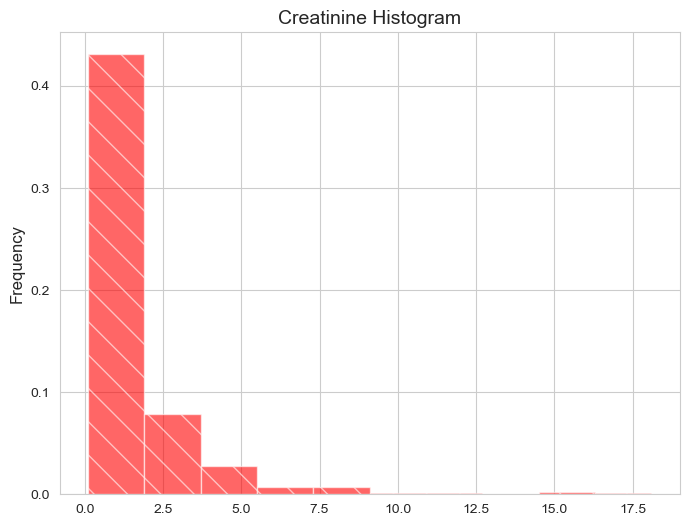

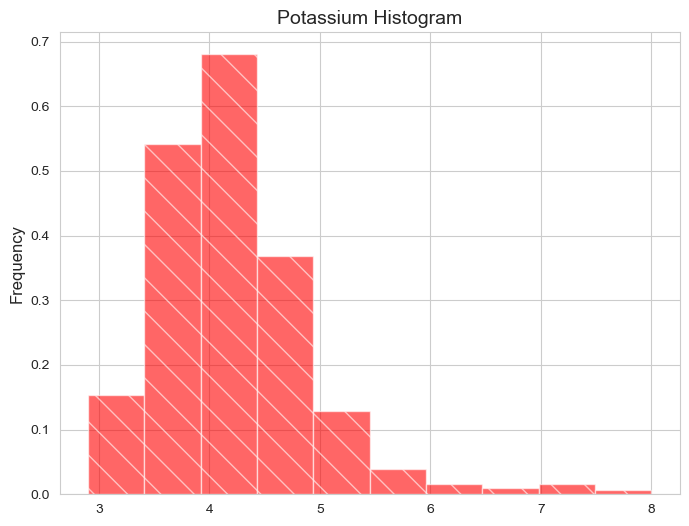

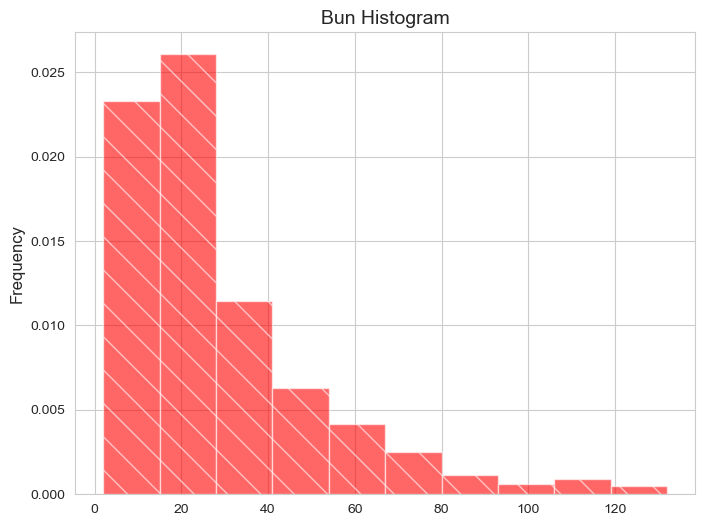

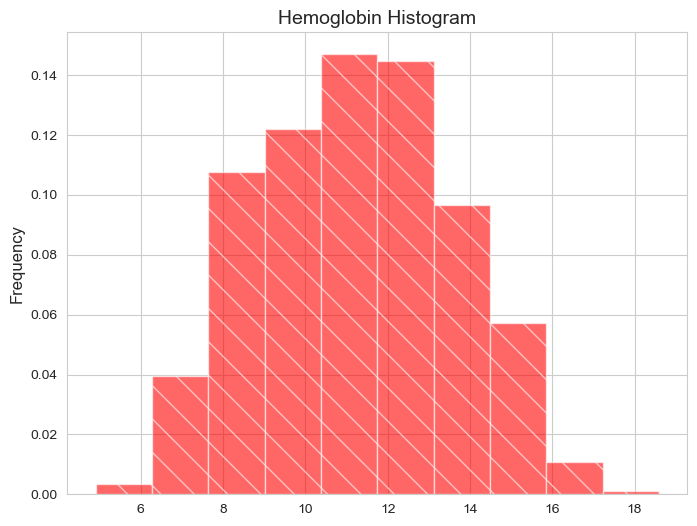

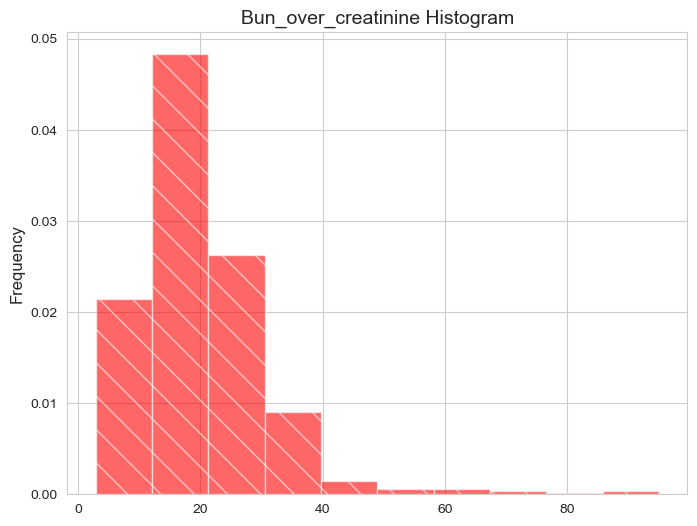

In [9]:
features = data_train.columns[:-1]
for feature in features:
    plt.figure(figsize = (8, 6))
    plt.hist(data_train[feature],
            color = 'red',
            hatch = '\\',
            alpha = 0.6,
            density = True)
    plt.ylabel('Frequency',
              fontsize = 12)
    plt.title(f'{feature.capitalize()} Histogram',
             fontsize = 14)
    plt.savefig(f'../Assets/{feature}_distribution')
    plt.show()

Next, we focus on feature-target relationships. For any given feature, such relationships are explored by constructing a separate histogram for each target class.  

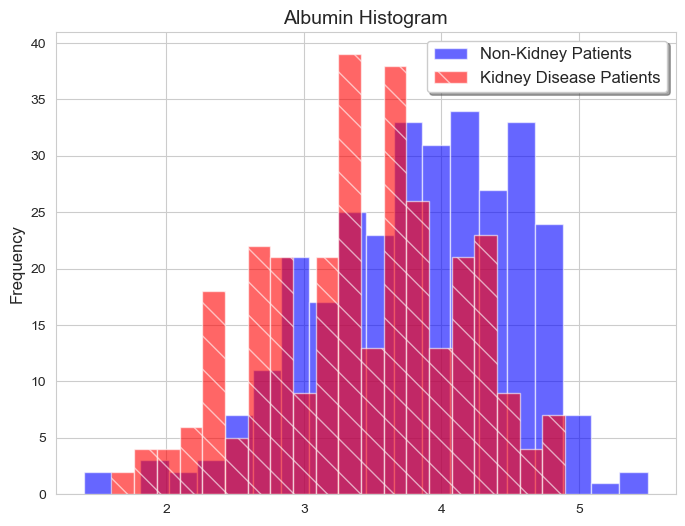

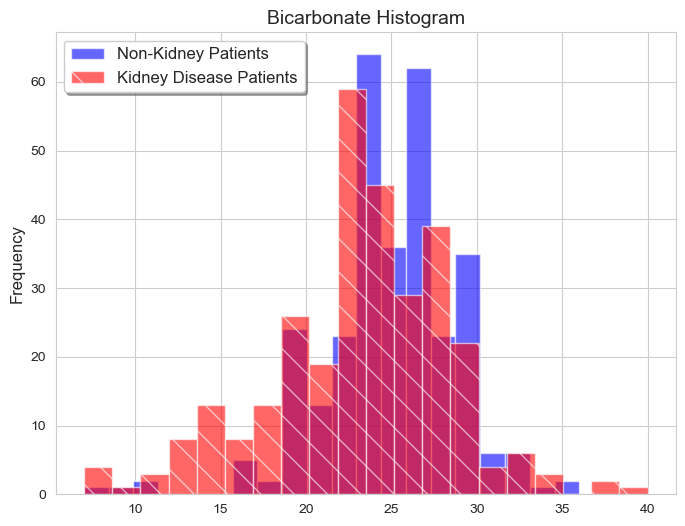

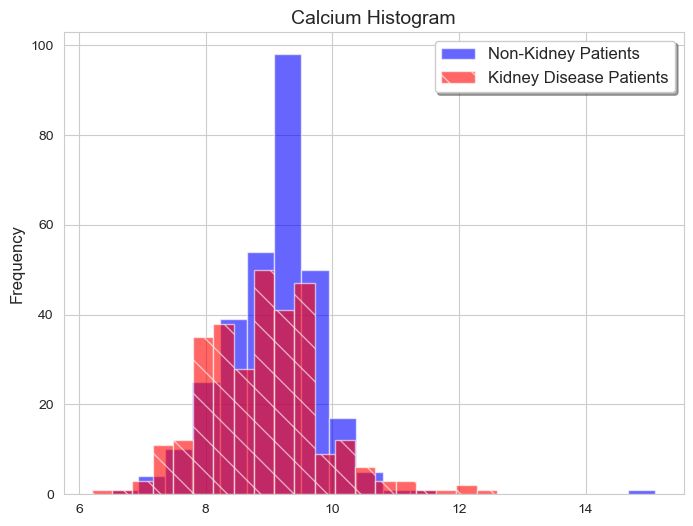

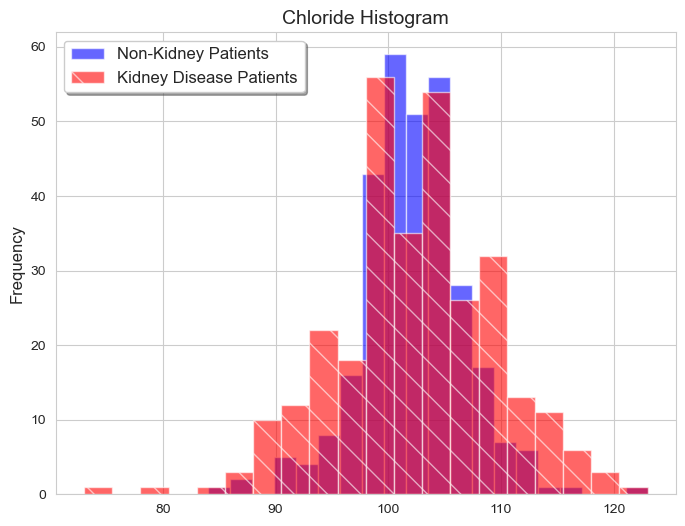

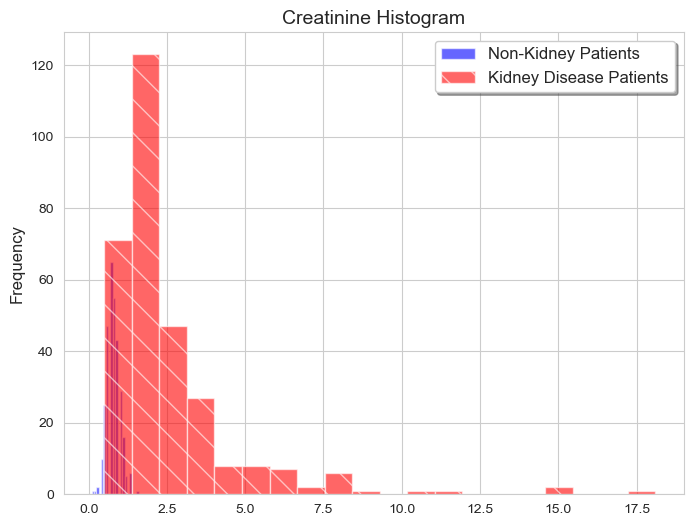

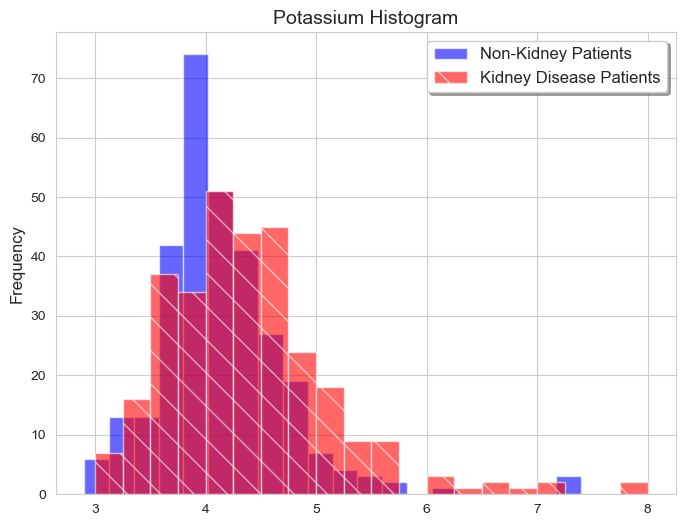

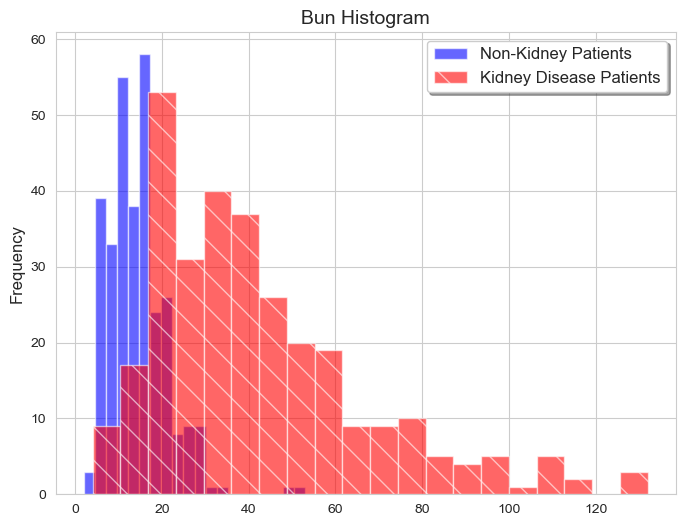

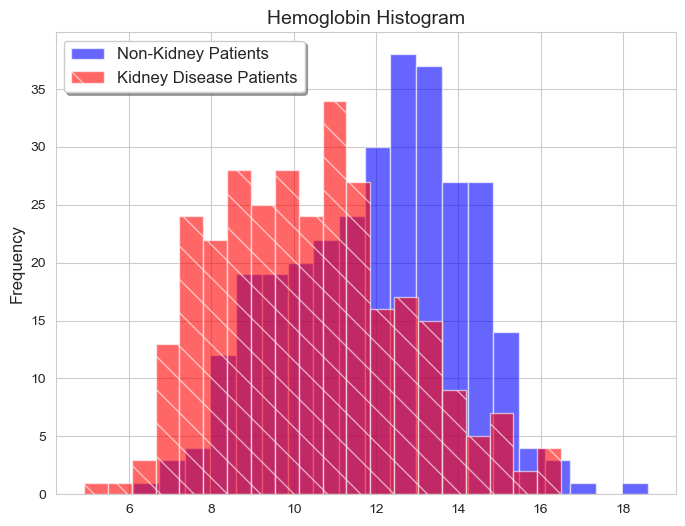

In [61]:
for feature in features:
    plt.figure(figsize = (8, 6))
    plt.hist(data_train.loc[data_train['class'] == 0, feature],
            color = 'blue',
            alpha = 0.6,
            bins = 20,
            label = 'Non-Kidney Patients')
    plt.hist(data_train.loc[data_train['class'] == 1, feature],
            color = 'red',
            hatch = '\\',
            alpha = 0.6,
            bins = 20,
            label = 'Kidney Disease Patients')
    plt.ylabel('Frequency',
              fontsize = 12)
    plt.title(f'{feature.capitalize()} Histogram',
             fontsize = 14)
    plt.legend(loc = 'best',
               fontsize = 12,
              fancybox = True,
              shadow = True)
    plt.savefig(f'../Data/{feature}_feature_target.png')
    plt.show()

The last part of this notebook explores relationships among the features. This is done by constructing pair plots and computing the correlation matrix 

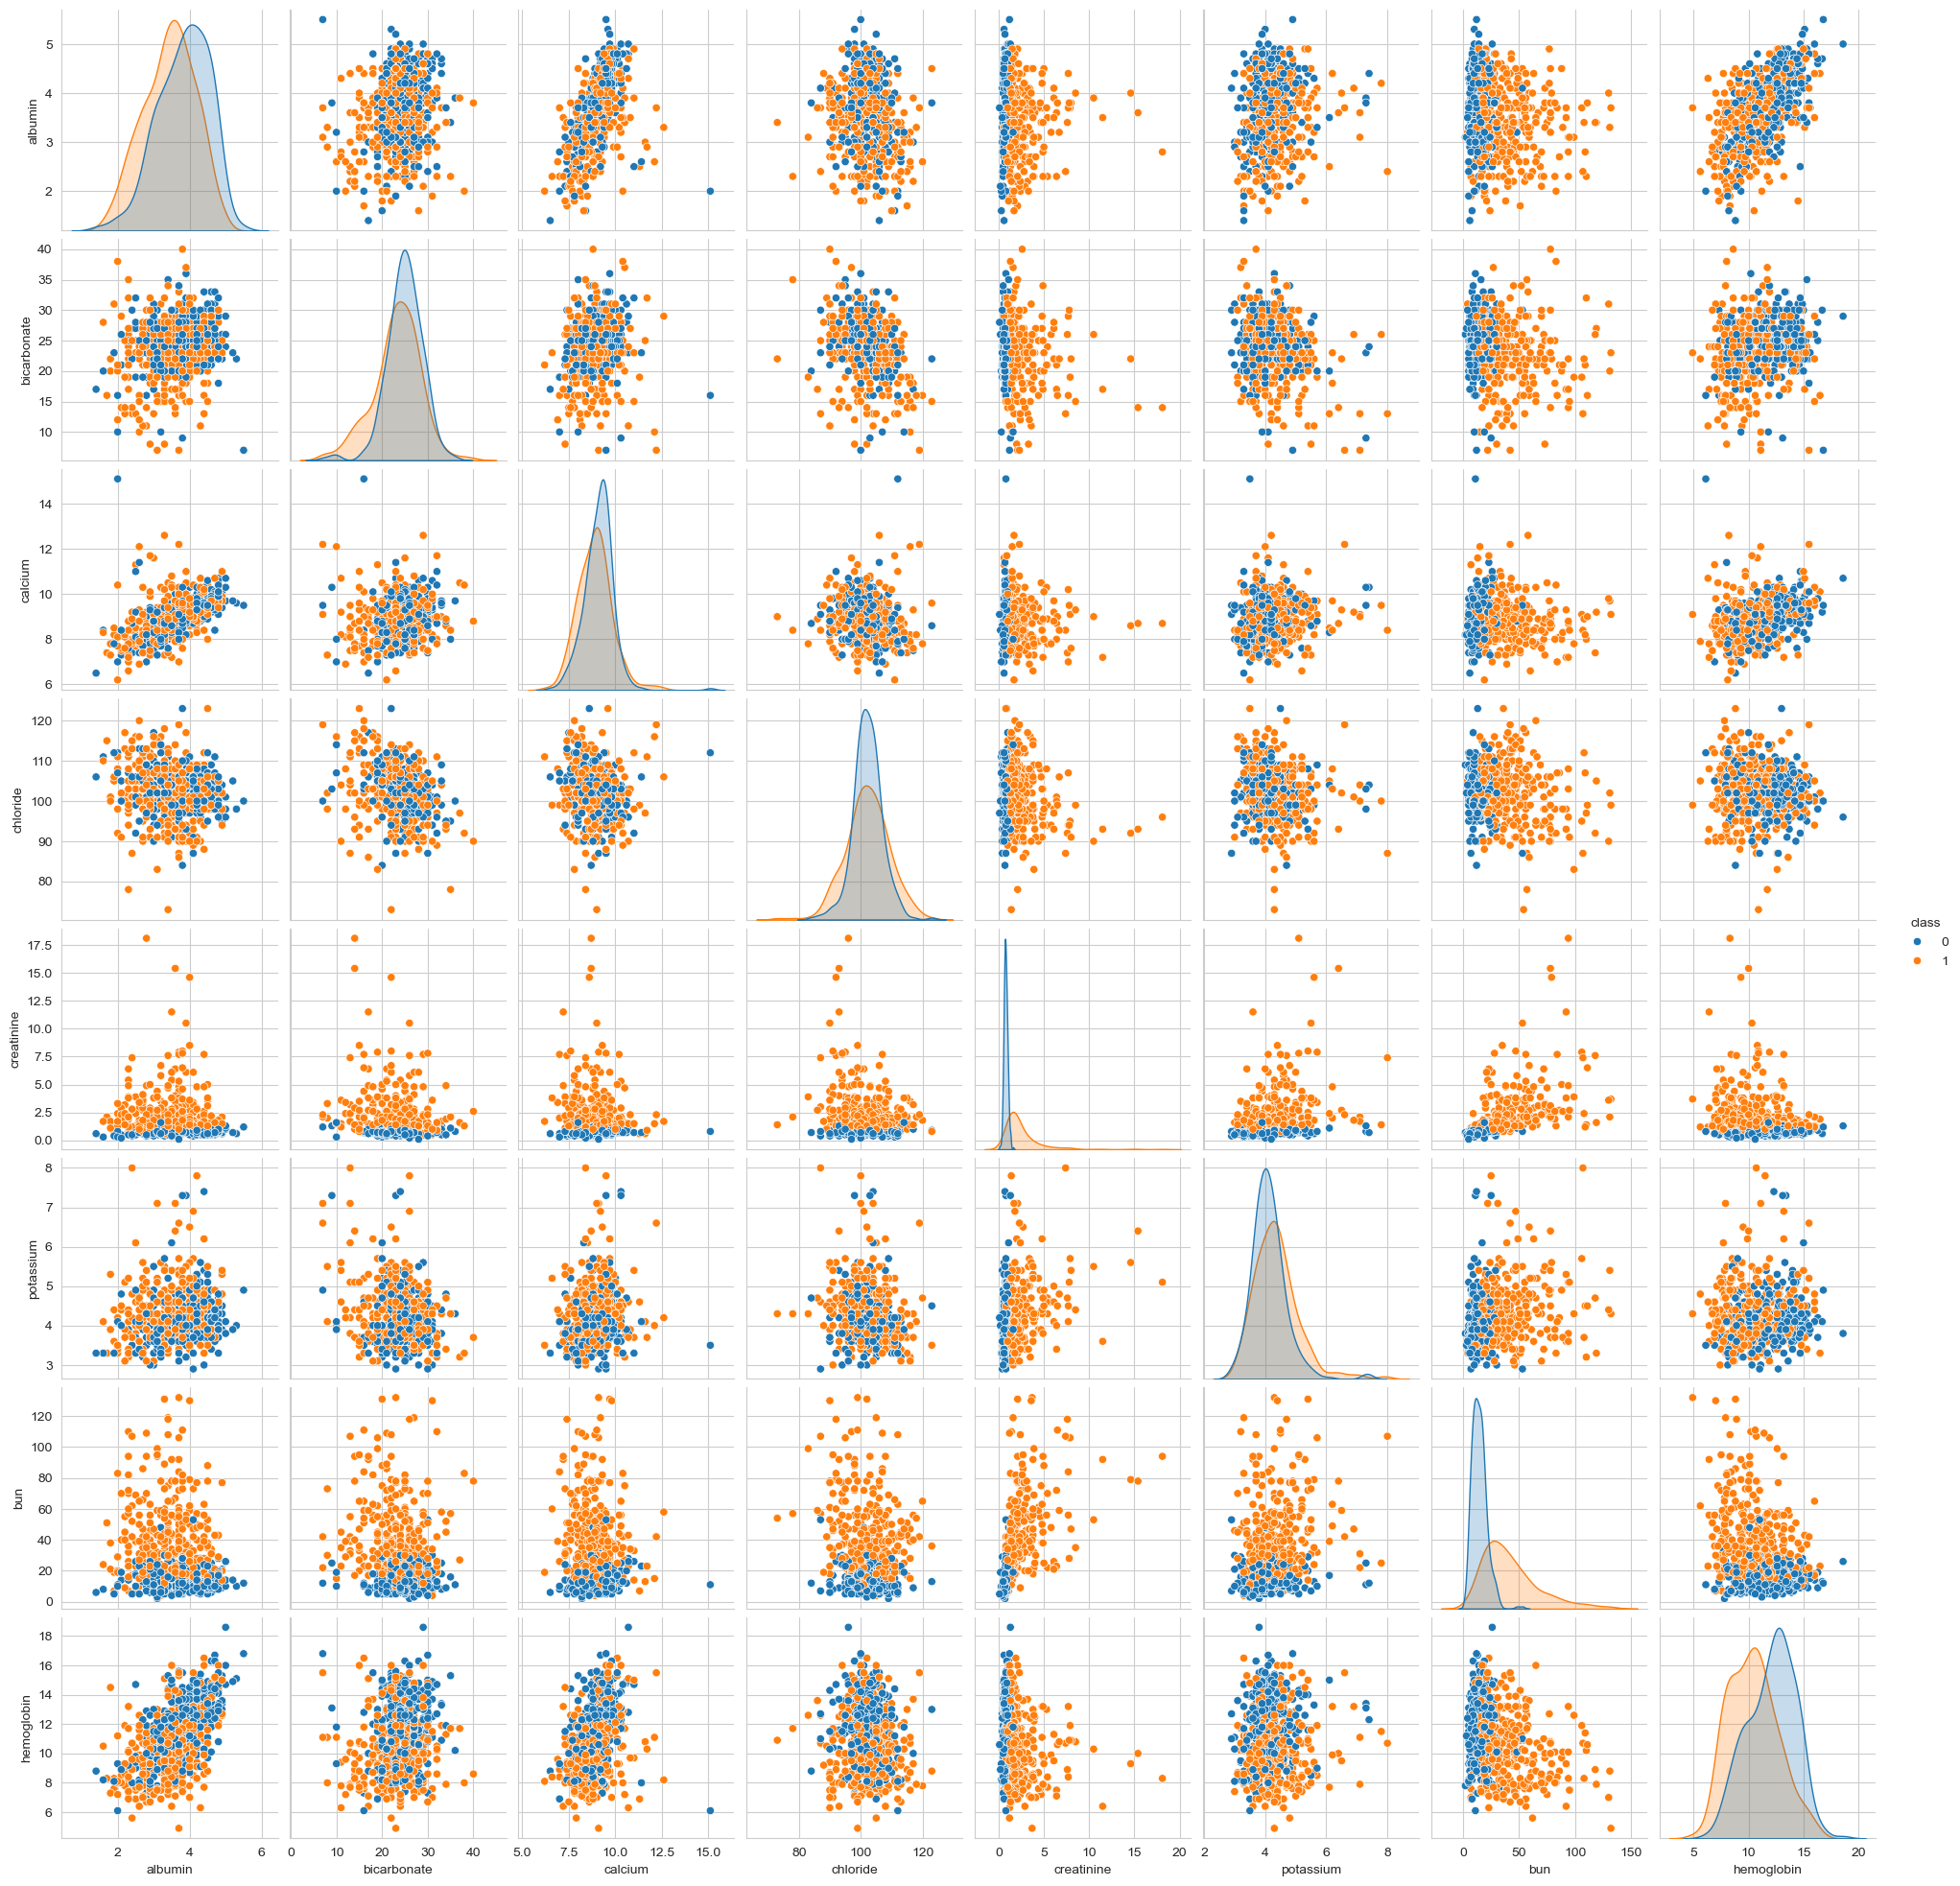

In [57]:
sns.pairplot(data_train,
            hue = 'class',
            x_vars = features,
            y_vars = features)
plt.show()

In [58]:
correlation_matrix = data_train[features].corr()
print(correlation_matrix)

              albumin  bicarbonate   calcium  chloride  creatinine  potassium  \
albumin      1.000000     0.201801  0.533837 -0.133920   -0.108297   0.127175   
bicarbonate  0.201801     1.000000  0.169899 -0.277230   -0.237389  -0.235126   
calcium      0.533837     0.169899  1.000000 -0.099255   -0.136692   0.136114   
chloride    -0.133920    -0.277230 -0.099255  1.000000   -0.203681  -0.129960   
creatinine  -0.108297    -0.237389 -0.136692 -0.203681    1.000000   0.277434   
potassium    0.127175    -0.235126  0.136114 -0.129960    0.277434   1.000000   
bun         -0.188345    -0.172076 -0.131118 -0.145535    0.594895   0.210557   
hemoglobin   0.612436     0.178427  0.352294 -0.067413   -0.245251   0.016772   

                  bun  hemoglobin  
albumin     -0.188345    0.612436  
bicarbonate -0.172076    0.178427  
calcium     -0.131118    0.352294  
chloride    -0.145535   -0.067413  
creatinine   0.594895   -0.245251  
potassium    0.210557    0.016772  
bun          1.000